# LLM Assistance Disclaimer

Parts of this code were developed with assistance from Large Language Models (specifically GitHub Copilot).
The models helped with implementation details, code structure, and documentation.
While the core ideas and algorithms are based on established research, the LLM assistance
improved code/documentation quality.

## Core imports and configuration

In [1]:
# Core imports and configuration
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import math
import os
from sklearn.model_selection import ParameterGrid

# MedMNIST
import medmnist
from medmnist import INFO

# Memory management for CUDA
torch.cuda.set_per_process_memory_fraction(0.7)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Configuration
DATA_FLAG = 'bloodmnist'
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE = 28  # BloodMNIST size

def set_seed(seed):
    """Set seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initial seed
INITIAL_SEED = 42
set_seed(INITIAL_SEED)

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")
print(f"Using device: {DEVICE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/
Using device: cuda


## Dataset information and data loading

In [2]:
# Dataset information
info = INFO[DATA_FLAG]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

# Blood cell type mapping
CELL_TYPES = {
    0: 'Basophil',
    1: 'Eosinophil', 
    2: 'Erythroblast',
    3: 'Immature Granulocyte',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}

print(f"Dataset: {DATA_FLAG}")
print(f"Task: {task}")
print(f"Number of channels: {n_channels}")
print(f"Number of classes: {n_classes}")
print(f"Image dimensions: {IMAGE_SIZE}x{IMAGE_SIZE}x{n_channels}")
print("\nCell Types:")
for idx, cell_type in CELL_TYPES.items():
    print(f"  {idx}: {cell_type}")

# Data preprocessing transforms
# For PixelCNN, we'll quantize to 256 levels (8 bits per channel)
data_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load dataset splits
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

# Use training dataset for training, validation for early stopping
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Create combined dataset for visualization and generation
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])
full_loader = DataLoader(
    full_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Total dataset size: {len(full_dataset)}")

Dataset: bloodmnist
Task: multi-class
Number of channels: 3
Number of classes: 8
Image dimensions: 28x28x3

Cell Types:
  0: Basophil
  1: Eosinophil
  2: Erythroblast
  3: Immature Granulocyte
  4: Lymphocyte
  5: Monocyte
  6: Neutrophil
  7: Platelet
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Train set size: 11959
Validation set size: 1712
Test set size: 3421
Total dataset size: 17092


## PixelCNN Masked Convolution Implementation

In [ ]:
class MaskedConv2d(nn.Conv2d):
    """
    Implements a masked convolution for PixelCNN.
    This ensures the autoregressive property by masking future pixels.
    
    The key innovation of PixelCNN is to enforce a specific ordering on pixels
    and ensure each pixel only depends on previously generated ones.
    """
    def __init__(self, in_channels, out_channels, kernel_size, 
                 mask_type='A', stride=1, padding='same', **kwargs):
        # Calculate appropriate padding for 'same' output size
        # This ensures output dimensions match input dimensions
        if padding == 'same':
            if isinstance(kernel_size, tuple):
                padding = ((kernel_size[0] - 1) // 2, (kernel_size[1] - 1) // 2)
            else:
                padding = (kernel_size - 1) // 2
        
        # Initialize the standard convolution layer
        super().__init__(in_channels, out_channels, kernel_size, 
                         stride=stride, padding=padding, **kwargs)
        
        # Register mask as a buffer (not a parameter) to ensure it's saved with model state
        # but not updated during backpropagation
        self.register_buffer('mask', torch.ones_like(self.weight))
        
        # Find the center point of the convolution kernel
        h, w = self.weight.shape[-2:]
        mid_h, mid_w = h // 2, w // 2
        
        # Create the appropriate mask based on the mask type:
        # - Type A: Used in the first layer, masks the center pixel and all future pixels
        #   This ensures the first layer doesn't have access to the current pixel
        # - Type B: Used in subsequent layers, only masks future pixels
        #   This allows connections to the current pixel from previous layers
        if mask_type == 'A':
            # Mask center pixel and all pixels to the right and below
            self.mask[:, :, mid_h, mid_w:] = 0  # Center and right
            self.mask[:, :, mid_h+1:, :] = 0    # Below
        elif mask_type == 'B':
            # Only mask pixels to the right of center and below
            # Importantly, the center pixel itself is kept (not masked)
            self.mask[:, :, mid_h, mid_w+1:] = 0  # Right of center
            self.mask[:, :, mid_h+1:, :] = 0      # Below
    
    def forward(self, x):
        # Apply mask to weights WITHOUT in-place modification
        # This avoids modifying the actual parameters during forward pass
        masked_weight = self.weight * self.mask
        
        # Use functional convolution with the masked weights
        # This performs standard convolution but with our masked weights
        return F.conv2d(
            x, 
            masked_weight, 
            bias=self.bias, 
            stride=self.stride,
            padding=self.padding,
            dilation=self.dilation,
            groups=self.groups
        )

## PixelCNN Core Components

In [ ]:
class ResidualBlock(nn.Module):
    """
    Residual block for PixelCNN.
    Uses masked convolutions to maintain the autoregressive property.
    
    Residual blocks help with training deeper networks by providing
    skip connections that mitigate the vanishing gradient problem.
    """
    def __init__(self, in_channels, out_channels=None, kernel_size=3):
        super().__init__()
        # If output channels not specified, use same as input channels
        if out_channels is None:
            out_channels = in_channels
            
        # First masked convolution layer - always type B to allow connections
        # to the current pixel from previous layers
        self.conv1 = MaskedConv2d(
            in_channels, out_channels, kernel_size, mask_type='B', padding='same'
        )
        # Second masked convolution layer
        self.conv2 = MaskedConv2d(
            out_channels, out_channels, kernel_size, mask_type='B', padding='same'
        )
        # Use separate ReLU instances to avoid in-place operations
        # In-place operations can cause issues with autograd during backpropagation
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        
        # Create a skip connection if dimensions change
        # This allows the input to bypass the main path if channels change
        if in_channels != out_channels:
            # 1x1 convolution to match dimensions
            self.skip_connection = MaskedConv2d(
                in_channels, out_channels, kernel_size=1, mask_type='B', padding=0
            )
        else:
            # If dimensions match, use identity mapping
            self.skip_connection = None
            
    def forward(self, x):
        # Save input for the residual connection
        residual = x
        
        # Main residual path
        # First convolutional layer with activation
        out = self.conv1(x)
        out = self.relu1(out)  # Non-in-place activation
        
        # Second convolutional layer
        out = self.conv2(out)
        
        # Process the skip connection if needed
        if self.skip_connection is not None:
            residual = self.skip_connection(residual)
            
        # Add the residual connection (shortcut)
        # Avoid in-place addition to prevent gradient issues
        out = out + residual
        out = self.relu2(out)  # Final activation
        
        return out


class PixelCNNLayer(nn.Module):
    """
    Standard layer of PixelCNN consisting of a single masked convolution.
    
    This is a simpler alternative to ResidualBlock when a straightforward
    convolution-activation pattern is needed without skip connections.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, mask_type='B'):
        super().__init__()
        # Single masked convolution
        self.conv = MaskedConv2d(
            in_channels, out_channels, kernel_size, mask_type=mask_type, padding='same'
        )
        # Non-in-place ReLU activation
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Apply convolution followed by activation
        x = self.conv(x)
        x = self.relu(x)  # Non-in-place activation
        return x

## PixelCNN Full Model Implementation

In [ ]:
class PixelCNN(nn.Module):
    """
    PixelCNN implementation that models the distribution of pixel values autoregressively.
    Uses masked convolutions to ensure pixels are only conditioned on previously generated ones.
    
    This architecture generates images pixel-by-pixel in a raster scan order (top-left to bottom-right),
    modeling each pixel conditioned on previously generated pixels.
    """
    def __init__(self, input_channels=3, hidden_dim=64, n_residual_blocks=5, n_layers=2, 
                 n_bits=8, use_residual=True):
        super().__init__()
        
        # Store configuration parameters
        self.input_channels = input_channels  # Number of color channels in the image
        self.hidden_dim = hidden_dim          # Width of hidden layers
        self.n_residual_blocks = n_residual_blocks  # Number of residual blocks if using residual architecture
        self.n_bits = n_bits                  # Bits per pixel channel for quantization
        self.n_layers = n_layers              # Number of standard layers if not using residual blocks
        
        # Calculate number of possible pixel values after quantization
        # For example, 8 bits allows 256 possible values per channel
        self.n_classes = 2**n_bits
        
        # Initial layer with mask_type A (crucial for proper autoregressive property)
        # Type A ensures the first layer doesn't see the current pixel
        self.initial_layer = MaskedConv2d(
            input_channels, hidden_dim, kernel_size=7, mask_type='A', padding=3
        )
        self.initial_relu = nn.ReLU()  # Non-in-place activation
        
        # Stack of hidden layers - different depending on architecture choice
        self.hidden_layers = nn.ModuleList()
        
        if use_residual:
            # Residual architecture (better for deeper networks)
            for i in range(n_residual_blocks):
                self.hidden_layers.append(ResidualBlock(hidden_dim, hidden_dim))
        else:
            # Standard architecture with simple convolutional layers
            for i in range(n_layers):
                self.hidden_layers.append(PixelCNNLayer(hidden_dim, hidden_dim))
        
        # Output network - predicts a probability distribution over possible pixel values
        # This consists of a 1x1 convolutional network that functions as a pixel-wise classifier
        self.output_relu1 = nn.ReLU()
        self.output_conv1 = MaskedConv2d(hidden_dim, hidden_dim, kernel_size=1, mask_type='B')
        self.output_relu2 = nn.ReLU()
        # Final layer outputs probability distribution for each channel and pixel
        self.output_conv2 = MaskedConv2d(hidden_dim, input_channels * self.n_classes, kernel_size=1, mask_type='B')
        
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x (Tensor): Input image tensor of shape [B, C, H, W]
            
        Returns:
            Tensor: Predicted distributions for each pixel with shape [B, C, n_classes, H, W]
                   This gives a probability distribution over possible values for each pixel.
        """
        batch_size, _, height, width = x.shape
        
        # Initial masked convolution - type A to enforce autoregressive property
        x = self.initial_layer(x)
        x = self.initial_relu(x)
        
        # Process through all hidden layers
        for layer in self.hidden_layers:
            x = layer(x)
        
        # Final prediction network
        x = self.output_relu1(x)
        x = self.output_conv1(x)
        x = self.output_relu2(x)
        x = self.output_conv2(x)
        
        # Reshape output to clearly separate the channel and class dimensions
        # From [B, C*n_classes, H, W] to [B, C, n_classes, H, W]
        x = x.reshape(batch_size, self.input_channels, self.n_classes, height, width)
        
        # Return logits (raw, unnormalized predictions)
        return x
    
    @torch.no_grad()
    def sample(self, n_samples, temp=1.0):
        """
        Sample new images from the trained model.
        
        This function generates images pixel-by-pixel in raster scan order,
        sampling each pixel from the predicted distribution conditioned on
        previously generated pixels.
        
        Args:
            n_samples (int): Number of samples to generate
            temp (float): Temperature for sampling (higher = more diverse, lower = more conservative)
            
        Returns:
            Tensor: Generated samples with shape [B, C, H, W] and values in [0,1]
        """
        # Initialize with zeros (the canvas for generation)
        # We use the same device as the model's parameters
        samples = torch.zeros(n_samples, self.input_channels, 28, 28, device=next(self.parameters()).device)
        
        # Generate pixels sequentially in raster scan order
        for h in tqdm(range(28), desc="Generating rows"):
            for w in range(28):
                # Get predicted distribution for all pixels given current state
                logits = self.forward(samples)  # [B, C, 256, H, W]
                
                # Extract the distribution for the current pixel position only
                pixel_logits = logits[:, :, :, h, w]  # [B, C, 256]
                
                # Apply temperature scaling to control randomness
                # Higher temp = more randomness, lower = more deterministic
                if temp != 1.0:
                    pixel_logits = pixel_logits / temp
                
                # Convert logits to probabilities with softmax
                pixel_probs = F.softmax(pixel_logits, dim=2)
                
                # Sample from the distribution for each image and channel
                pixel_values = torch.multinomial(pixel_probs.reshape(n_samples * self.input_channels, -1), 1)
                pixel_values = pixel_values.reshape(n_samples, self.input_channels)
                
                # Normalize values to [0, 1] range for image representation
                pixel_values = pixel_values.float() / (self.n_classes - 1)
                
                # Place sampled pixel values at current position in our samples
                samples[:, :, h, w] = pixel_values
        
        # Return the completed generated samples
        return samples

## FID implementation

In [ ]:
# Import the linalg module from scipy for matrix operations
from scipy import linalg

class InceptionV3Features(nn.Module):
    """
    Feature extractor using InceptionV3 for FID calculation.
    
    Fréchet Inception Distance (FID) is a metric that measures the similarity between
    two distributions of images. It uses the Inception v3 model to extract features
    from both real and generated images.
    """
    def __init__(self):
        super().__init__()
        # Load pre-trained Inception v3 model
        from torchvision.models import inception_v3, Inception_V3_Weights
        self.inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        # Replace the final fully connected layer with identity to get features
        self.inception.fc = nn.Identity()
        # Disable auxiliary logits to simplify the model
        self.inception.aux_logits = False
        
    def forward(self, x):
        # Resize images to 299x299 as required by Inception v3
        x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        
        # Normalize pixel values if needed
        if x.min() < 0:
            x = (x + 1) / 2
            
        # Convert grayscale to RGB by repeating the channel if needed
        # Inception requires 3-channel inputs
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
            
        # Return feature vectors
        return self.inception(x)

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2):
    """
    Calculate the Fréchet distance between two multivariate Gaussians.
    
    Args:
        mu1 (numpy.ndarray): Mean of the first Gaussian
        sigma1 (numpy.ndarray): Covariance matrix of the first Gaussian
        mu2 (numpy.ndarray): Mean of the second Gaussian
        sigma2 (numpy.ndarray): Covariance matrix of the second Gaussian
        
    Returns:
        float: The Fréchet distance
    """
    # Calculate mean difference term
    diff = mu1 - mu2
    
    # Calculate sqrt of product of covariances with numerical stability handling
    # This can be numerically unstable if the matrices are near-singular
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        # Add a small regularization term if matrices are ill-conditioned
        offset = np.eye(sigma1.shape[0]) * 1e-6
        covmean = linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))
    
    # Handle numerical errors that may produce small imaginary components
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    tr_covmean = np.trace(covmean)
    
    # Final FID formula: ||mu_1 - mu_2||^2 + Tr(Σ_1 + Σ_2 - 2√(Σ_1Σ_2))
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

def compute_fid(real_images, generated_images, batch_size=32, device=torch.device("cuda")):
    """
    Calculate the Fréchet Inception Distance between real and generated images.
    
    Args:
        real_images (torch.Tensor): Tensor of real images [N, C, H, W]
        generated_images (torch.Tensor): Tensor of generated images [N, C, H, W]
        batch_size (int): Batch size for feature extraction
        device (torch.device): Device to use for computation
        
    Returns:
        float: The computed FID score (lower is better)
    """
    # Create InceptionV3 model instance for feature extraction
    inception = InceptionV3Features().to(device)
    inception.eval()
    
    # Helper function to compute mean and covariance of features
    def compute_statistics(images):
        features = []
        # Process images in batches to conserve memory
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            with torch.no_grad():
                feat = inception(batch)
            # Move features to CPU to save GPU memory
            features.append(feat.cpu().numpy())
        
        # Concatenate all features
        features = np.concatenate(features, axis=0)
        # Calculate mean feature vector
        mu = np.mean(features, axis=0)
        # Calculate covariance matrix
        sigma = np.cov(features, rowvar=False)
        return mu, sigma
    
    # Calculate statistics for real and generated images
    mu_real, sigma_real = compute_statistics(real_images)
    mu_fake, sigma_fake = compute_statistics(generated_images)
    
    # Calculate the FID score using the statistics
    fid = calculate_frechet_distance(mu_real, sigma_real, mu_fake, sigma_fake)
    
    # Clean up GPU memory
    torch.cuda.empty_cache()
    
    return fid

## Training and Evaluation Functions

In [ ]:
def train_epoch(model, optimizer, train_loader, device, 
                n_bits=8, n_bins=256, epoch=0):
    """
    Train the PixelCNN model for one complete epoch.
    
    This function handles:
    - Forward and backward passes
    - Gradient updates
    - Loss calculation and tracking
    - Memory management
    
    Args:
        model: The PixelCNN model
        optimizer: PyTorch optimizer for parameter updates
        train_loader: DataLoader providing training batches
        device: Device to perform training on (GPU/CPU)
        n_bits: Bit depth for pixel quantization
        n_bins: Number of bins for pixel values (2^n_bits)
        epoch: Current epoch number (for logging)
        
    Returns:
        float: Average loss for the epoch
    """
    # Set model to training mode
    model.train()
    total_loss = 0
    
    # Create progress bar with tqdm for visual feedback during training
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), 
                desc=f"Epoch {epoch+1} [Train]", leave=False)
    
    for batch_idx, (x, _) in pbar:
        # Move data to appropriate device (GPU/CPU)
        x = x.to(device)
        batch_size = x.shape[0]
        
        # Prepare target data by quantizing to n_bits
        # This converts continuous values to discrete bins for classification
        if n_bits < 8:
            # For lower bit depths, scale appropriately
            x_quantized = torch.floor(x * n_bins).long().clamp(0, n_bins-1)
        else:
            # For 8-bit images (standard), scale to [0,255]
            x_quantized = (x * (n_bins - 1)).long().clamp(0, n_bins-1)
        
        # Reset gradients before backward pass
        optimizer.zero_grad()
        
        # Forward pass: get predicted distributions for each pixel
        logits = model(x)
        
        # Calculate negative log-likelihood loss
        loss = discretized_mix_logistic_loss(logits, x_quantized)
        
        # Backward pass: compute gradient of the loss
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update model parameters
        optimizer.step()
        
        # Track total loss for epoch average
        total_loss += loss.item()
        
        # Update progress bar with current loss value
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        # Periodically clear CUDA cache to prevent memory issues
        if batch_idx % 25 == 0:
            torch.cuda.empty_cache()
    
    # Return average loss over all batches
    return total_loss / len(train_loader)


def validate(model, val_loader, device, n_bits=8, n_bins=256):
    """
    Evaluate the model on a validation set.
    
    Args:
        model: The PixelCNN model
        val_loader: DataLoader providing validation batches
        device: Device to perform evaluation on
        n_bits: Bit depth for pixel quantization
        n_bins: Number of bins for pixel values (2^n_bits)
        
    Returns:
        float: Average validation loss
    """
    # Set model to evaluation mode (disables dropout, etc.)
    model.eval()
    total_loss = 0
    
    # No gradient computation needed for validation
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(val_loader):
            # Move data to device
            x = x.to(device)
            
            # Quantize pixel values
            if n_bits < 8:
                x_quantized = torch.floor(x * n_bins).long().clamp(0, n_bins-1)
            else:
                x_quantized = (x * (n_bins - 1)).long().clamp(0, n_bins-1)
            
            # Forward pass only
            logits = model(x)
            
            # Calculate loss
            loss = discretized_mix_logistic_loss(logits, x_quantized)
            
            # Accumulate loss
            total_loss += loss.item()
    
    # Return average validation loss
    return total_loss / len(val_loader)


def discretized_mix_logistic_loss(logits, target):
    """
    Calculate cross-entropy loss for discretized pixel values.
    
    This loss function treats each pixel value as a classification problem
    with n_classes possible values.
    
    Args:
        logits: Model output with shape [B, C, n_classes, H, W]
                representing class logits for each pixel
        target: Target indices with shape [B, C, H, W]
                representing the ground truth pixel class indices
        
    Returns:
        loss: Scalar loss value (average negative log-likelihood)
    """
    batch_size, n_channels, n_classes, height, width = logits.shape
    
    # Reshape tensors to treat each pixel as independent classification problem
    # First permute to bring the class dimension to the end
    logits = logits.permute(0, 1, 3, 4, 2)  # [B, C, H, W, n_classes]
    # Then flatten all dimensions except the class dimension
    logits = logits.reshape(-1, n_classes)   # [B*C*H*W, n_classes]
    
    # Flatten target to match logits
    target = target.reshape(-1)  # [B*C*H*W]
    
    # Standard cross entropy loss
    loss = F.cross_entropy(logits, target)
    
    return loss


def generate_samples(model, n_samples=16, device=torch.device('cuda'), temp=1.0):
    """
    Generate novel samples from a trained PixelCNN model.
    
    Args:
        model: Trained PixelCNN model
        n_samples: Number of samples to generate
        device: Device to use for generation
        temp: Temperature for sampling (higher = more diverse, lower = more conservative)
        
    Returns:
        torch.Tensor: Generated sample images with shape [n_samples, C, H, W]
    """
    # Set model to evaluation mode
    model.eval()
    
    # Use the model's sampling method to generate new images
    # This process is autoregressive, generating each pixel conditioned on previous ones
    samples = model.sample(n_samples, temp=temp)
    
    return samples


def visualize_samples(samples, title="Generated Samples"):
    """
    Visualize a batch of generated samples in a grid layout.
    
    Args:
        samples: Tensor of images to visualize [N, C, H, W]
        title: Title for the plot
    """
    # Create a grid of images
    grid = make_grid(samples, nrow=int(np.sqrt(len(samples))))
    
    # Display the grid
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

## Training loop with early stopping

In [ ]:
def train_pixelcnn(model, train_loader, val_loader, hyperparams, device,
                  n_bits=8, patience=10):
    """
    Train a PixelCNN model with early stopping based on validation loss.
    
    This function handles the complete training process including:
    - Optimization setup
    - Learning rate scheduling
    - Early stopping
    - Model checkpointing
    - Training/validation loss tracking
    - Periodic sample generation
    
    Args:
        model: PixelCNN model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        hyperparams: Dictionary of hyperparameters
        device: Device to perform training on (GPU/CPU)
        n_bits: Bit depth for pixel quantization
        patience: Number of epochs to wait for improvement before early stopping
        
    Returns:
        tuple: (trained_model, train_losses, val_losses, best_validation_loss)
    """
    
    # Extract hyperparameters from the configuration dictionary
    lr = hyperparams['lr']                            # Learning rate
    epochs = hyperparams['epochs']                    # Maximum number of epochs
    weight_decay = hyperparams.get('weight_decay', 0.0)  # L2 regularization strength
    
    # Calculate number of bins for pixel value quantization
    # For example, 8 bits gives 256 possible values per channel
    n_bins = 2**n_bits
    
    # Setup Adam optimizer with weight decay for regularization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Setup learning rate scheduler to reduce LR when validation loss plateaus
    # This helps navigate flat regions and local minima in the loss landscape
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
    
    # Initialize early stopping variables
    best_val_loss = float('inf')    # Track best validation loss
    best_model_state = None         # Save best model weights
    no_improvement = 0              # Count epochs without improvement
    
    # Initialize lists to track metrics
    train_losses = []
    val_losses = []
    
    # Display hyperparameter configuration
    print(f"Starting PixelCNN training with hyperparameters: {hyperparams}")
    
    # Main training loop
    for epoch in range(epochs):
        # Train for one epoch and get average training loss
        train_loss = train_epoch(
            model, optimizer, train_loader, device, 
            n_bits=n_bits, n_bins=n_bins, epoch=epoch
        )
        
        # Evaluate on validation set
        val_loss = validate(model, val_loader, device, n_bits=n_bits, n_bins=n_bins)
        
        # Update learning rate based on validation performance
        scheduler.step(val_loss)
        
        # Store losses for later analysis
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Display progress for current epoch
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # Check if we have a new best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Create a deep copy of model weights to avoid reference issues
            best_model_state = model.state_dict().copy()
            no_improvement = 0
            print(f"New best validation loss: {best_val_loss:.6f}")
            
            # Periodically generate and visualize samples to track progress
            # This helps monitor the quality of generated images during training
            if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
                samples = generate_samples(model, n_samples=16, device=device)
                visualize_samples(samples, title=f"Samples at Epoch {epoch+1}")
        else:
            # Increment counter if no improvement in validation loss
            no_improvement += 1
            print(f"No improvement for {no_improvement} epochs")
            
        # Check early stopping condition
        if no_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load the weights from the best epoch before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Return the trained model and training history
    return model, train_losses, val_losses, best_val_loss

## Hyperparameter tuning for PixelCNN

In [ ]:
def tune_pixelcnn(train_loader, val_loader, test_loader, param_grid, device, n_bits=8, n_samples_fid=500):
    """
    Perform hyperparameter tuning for PixelCNN using the Fréchet Inception Distance (FID) metric.
    
    This function systematically evaluates different hyperparameter combinations to find
    the configuration that produces the best quality generated images as measured by FID.
    
    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        test_loader: DataLoader for test data (used for FID evaluation)
        param_grid: Dictionary defining the hyperparameter search space
        device: Device to use for computation (GPU/CPU)
        n_bits: Bit depth for pixel quantization
        n_samples_fid: Number of samples to use for FID calculation
        
    Returns:
        dict: Best hyperparameter configuration and results
    """
    # Convert parameter grid to list of specific combinations to try
    hyperparameter_combinations = list(ParameterGrid(param_grid))
    print(f"Total combinations: {len(hyperparameter_combinations)}")
    
    # Initialize list to store results for each combination
    results = []
    
    # Sample real images from test set for FID comparison
    # These will be used as the reference distribution
    real_batch, _ = next(iter(test_loader))
    real_samples = real_batch[:n_samples_fid].to(device)
    
    # Evaluate each hyperparameter combination
    for i, hyperparams in enumerate(hyperparameter_combinations):
        print(f"\nHyperparameter combination {i+1}/{len(hyperparameter_combinations)}")
        print(f"Configuration: {hyperparams}")
        
        # Clear GPU memory before starting
        torch.cuda.empty_cache()
        
        # Set seed for reproducibility across different combinations
        # Using a different seed for each combination ensures fair comparison
        set_seed(INITIAL_SEED + i)
        
        try:
            # Initialize model with current hyperparameters
            model = PixelCNN(
                input_channels=n_channels,
                hidden_dim=hyperparams['hidden_dim'],
                n_residual_blocks=hyperparams['n_residual_blocks'],
                n_bits=n_bits,
                use_residual=hyperparams['use_residual']
            ).to(device)
            
            # Train model using validation set for early stopping
            trained_model, train_losses, val_losses, best_val_loss = train_pixelcnn(
                model,
                train_loader,
                val_loader,
                hyperparams,
                device,
                n_bits=n_bits,
                patience=hyperparams.get('patience', 10)
            )
            
            # Generate samples for FID calculation
            # These represent the model's learned distribution
            fake_samples = generate_samples(trained_model, n_samples=n_samples_fid, device=device)
            
            # Calculate FID score between real and generated samples
            # Lower FID indicates better quality and more realistic generations
            fid_score = compute_fid(real_samples, fake_samples, batch_size=32, device=device)
            print(f"FID Score: {fid_score:.4f}")
            
            # Generate a smaller batch of samples for visual inspection
            vis_samples = generate_samples(trained_model, n_samples=16, device=device)
            visualize_samples(vis_samples, title=f"Final Samples - Config {i+1}")
            
            # Save detailed results for this configuration
            results.append({
                'hyperparams': hyperparams,
                'best_val_loss': best_val_loss,
                'fid_score': fid_score,
                'model_state': trained_model.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses
            })
            
            # Save checkpoint after each combination in case of crashes
            torch.save({
                'results': results,
                'last_idx': i
            }, f'pixelcnn_checkpoint_{i}.pth')
            
            print(f"Best validation loss: {best_val_loss:.6f}, FID Score: {fid_score:.4f}")
            
        except RuntimeError as e:
            # Handle out of memory errors gracefully
            if 'CUDA out of memory' in str(e):
                print(f"CUDA out of memory error on combination {i+1}. Skipping this combination.")
                print(f"Error details: {str(e)}")
                # Log the failure but continue with other combinations
                results.append({
                    'hyperparams': hyperparams,
                    'best_val_loss': float('inf'),
                    'fid_score': float('inf'),
                    'error': 'CUDA OOM'
                })
                # Clear GPU cache and continue
                torch.cuda.empty_cache()
                continue
            else:
                # Re-raise other types of errors
                raise e
        
        # Clean up resources to prevent memory leaks
        del model, trained_model
        torch.cuda.empty_cache()
    
    # Filter out failed runs and find best configuration based on FID score
    valid_results = [r for r in results if 'error' not in r]
    
    if valid_results:
        # Sort by FID score (lower is better)
        valid_results.sort(key=lambda x: x['fid_score'])
        
        best_result = valid_results[0]
        print("\n=== Best Hyperparameter Configuration ===")
        print(f"Best FID Score: {best_result['fid_score']:.4f}")
        print(f"Configuration: {best_result['hyperparams']}")
        
        # Save the best model for future use
        torch.save({
            'model_state': best_result['model_state'],
            'hyperparams': best_result['hyperparams'],
            'best_val_loss': best_result['best_val_loss'],
            'fid_score': best_result['fid_score']
        }, 'best_bloodmnist_pixelcnn.pth')
        
        return best_result
    else:
        print("No valid combinations completed successfully.")
        return None

## Evaluation and Sampling

In [ ]:
def evaluate_on_test_set(model, test_loader, device, n_bits=8):
    """
    Evaluate a trained PixelCNN model on the test set.
    
    This function calculates the average loss on the entire test set,
    which serves as a final measure of model performance.
    
    Args:
        model: Trained PixelCNN model
        test_loader: DataLoader for test data
        device: Device to perform evaluation on (GPU/CPU)
        n_bits: Bit depth for pixel quantization
        
    Returns:
        float: Average test loss
    """
    # Set model to evaluation mode
    model.eval()
    n_bins = 2**n_bits
    total_loss = 0
    
    # Use torch.no_grad() to disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(tqdm(test_loader, desc="Evaluating on test set")):
            # Move data to appropriate device
            x = x.to(device)
            
            # Quantize pixel values to discrete bins based on bit depth
            if n_bits < 8:
                # For lower bit depths, scale appropriately
                x_quantized = torch.floor(x * n_bins).long().clamp(0, n_bins-1)
            else:
                # For 8-bit images (standard), scale to [0,255]
                x_quantized = (x * (n_bins - 1)).long().clamp(0, n_bins-1)
            
            # Forward pass through the model
            logits = model(x)
            
            # Calculate negative log-likelihood loss
            loss = discretized_mix_logistic_loss(logits, x_quantized)
            
            # Accumulate batch loss
            total_loss += loss.item()
    
    # Calculate and report average loss
    avg_loss = total_loss / len(test_loader)
    print(f"Test set loss: {avg_loss:.6f}")
    return avg_loss


def generate_samples_with_multiple_temperatures(model, n_samples=16, device=torch.device('cuda')):
    """
    Generate samples using different temperature settings for comparison.
    
    Temperature controls the randomness in sampling:
    - Lower temperatures produce more conservative, higher-probability samples
    - Higher temperatures produce more diverse, exploratory samples
    
    Args:
        model: Trained PixelCNN model
        n_samples: Number of samples to generate per temperature
        device: Device to use for generation
        
    Returns:
        list: List of sample batches at different temperatures
    """
    model.eval()
    
    # Define a range of temperatures to explore
    temperatures = [0.5, 0.75, 1.0, 1.25]
    all_samples = []
    
    # Create a figure for visualization
    plt.figure(figsize=(15, 15))
    
    # Generate samples for each temperature
    for i, temp in enumerate(temperatures):
        print(f"Generating samples with temperature = {temp}")
        
        # Generate samples at current temperature
        samples = model.sample(n_samples=n_samples, temp=temp)
        all_samples.append(samples)
        
        # Create subplot for this temperature
        plt.subplot(2, 2, i+1)
        grid = make_grid(samples, nrow=int(np.sqrt(n_samples)))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.title(f"Temperature = {temp}")
        plt.axis('off')
    
    # Display the composite figure with all temperatures
    plt.tight_layout()
    plt.show()
    
    return all_samples


def compare_real_and_generated(model, test_loader, n_samples=32, device=torch.device('cuda')):
    """
    Create a visual comparison between real data samples and model-generated ones.
    
    This is crucial for qualitatively evaluating the model's performance
    and identifying any systematic differences between real and generated data.
    
    Args:
        model: Trained PixelCNN model
        test_loader: DataLoader providing test samples
        n_samples: Number of samples to compare
        device: Device to use for computation
    """
    # Extract a batch of real samples from the test set
    real_batch, _ = next(iter(test_loader))
    real_samples = real_batch[:n_samples].to(device)
    
    # Generate an equal number of synthetic samples
    generated_samples = model.sample(n_samples=n_samples)
    
    # Create a side-by-side visualization
    plt.figure(figsize=(12, 6))
    
    # Display real samples on the left
    plt.subplot(1, 2, 1)
    real_grid = make_grid(real_samples, nrow=int(np.sqrt(n_samples)))
    plt.imshow(real_grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Real Samples")
    plt.axis('off')
    
    # Display generated samples on the right
    plt.subplot(1, 2, 2)
    gen_grid = make_grid(generated_samples, nrow=int(np.sqrt(n_samples)))
    plt.imshow(gen_grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Generated Samples")
    plt.axis('off')
    
    # Show the comparison
    plt.tight_layout()
    plt.show()

## Multi-seed evaluation for robustness

In [ ]:
def evaluate_with_multiple_seeds(model_class, best_hyperparams, train_loader, test_loader, seeds, device, n_bits=8, n_samples_fid=500):
    """
    Evaluate model robustness by training and testing with multiple random seeds.
    
    This function is crucial for assessing the stability and reliability of the model.
    ML models can be sensitive to initialization, so running multiple seeds helps
    determine whether good performance is consistent or due to a lucky random start.
    
    Args:
        model_class: The model class to instantiate
        best_hyperparams: Best hyperparameters found from tuning
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        seeds: List of random seeds to use
        device: Device to use for computation
        n_bits: Bit depth for pixel quantization
        n_samples_fid: Number of samples to use for FID calculation
        
    Returns:
        dict: Results containing mean FID, std deviation, and individual scores
    """
    print("\n=== Evaluating PixelCNN with Multiple Seeds ===")
    
    # Track scores and samples across runs
    fid_scores = []
    generated_samples = []
    
    # Get real samples for consistent FID comparison across all seeds
    real_batch, _ = next(iter(test_loader))
    real_samples = real_batch[:n_samples_fid].to(device)
    
    # Run evaluation for each seed
    for run_idx, seed in enumerate(seeds):
        print(f"\nEvaluation {run_idx+1}/{len(seeds)} with seed {seed}")
        
        # Set random seed for reproducibility
        set_seed(seed)
        
        # Initialize model with the best hyperparameters
        model = model_class(
            input_channels=n_channels,
            hidden_dim=best_hyperparams['hidden_dim'],
            n_residual_blocks=best_hyperparams['n_residual_blocks'],
            n_bits=n_bits,
            use_residual=best_hyperparams['use_residual']
        ).to(device)
        
        # Setup optimizer with the best learning rate and regularization
        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=best_hyperparams['lr'],
            weight_decay=best_hyperparams['weight_decay']
        )
        
        # Configuration for training
        epochs = best_hyperparams.get('epochs', 30)
        patience = best_hyperparams.get('patience', 10)
        
        # Initialize training state variables
        best_val_loss = float('inf')
        best_model_state = None
        no_improvement = 0
        n_bins = 2**n_bits
        
        # Training logs
        train_losses = []
        val_losses = []
        
        print(f"Training with seed {seed}")
        
        # Training loop for current seed
        for epoch in range(epochs):
            # Train for one epoch
            train_loss = train_epoch(
                model, optimizer, train_loader, device, 
                n_bits=n_bits, n_bins=n_bins, epoch=epoch
            )
            
            # Evaluate on validation set
            val_loss = validate(model, val_loader, device, n_bits=n_bits, n_bins=n_bins)
            
            # Track losses
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            # Display progress
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
            
            # Check for improvement in validation loss
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()
                no_improvement = 0
            else:
                no_improvement += 1
                
            # Implement early stopping
            if no_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        # Load best model state for evaluation
        model.load_state_dict(best_model_state)
        
        # Generate samples to evaluate with FID
        fake_samples = generate_samples(model, n_samples=n_samples_fid, device=device)
        
        # Calculate FID score for this seed
        fid_score = compute_fid(real_samples, fake_samples, batch_size=32, device=device)
        fid_scores.append(fid_score)
        
        # Generate smaller sample set for visualization
        vis_samples = generate_samples(model, n_samples=16, device=device)
        generated_samples.append(vis_samples)
        
        # Display these samples
        visualize_samples(vis_samples, title=f"Samples with Seed {seed} - FID: {fid_score:.4f}")
    
    # Calculate statistical measures across seeds
    mean_fid = np.mean(fid_scores)
    std_fid = np.std(fid_scores)
    
    # Report results
    print("\n=== Robustness Evaluation Results ===")
    print(f"Mean FID Score: {mean_fid:.4f} ± {std_fid:.4f}")
    for i, (seed, fid) in enumerate(zip(seeds, fid_scores)):
        print(f"Evaluation {i+1} (Seed {seed}): FID = {fid:.4f}")
    
    # Create visualization of FID scores across seeds
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(seeds)+1), fid_scores, color='skyblue', alpha=0.7)
    plt.axhline(y=mean_fid, color='r', linestyle='-', label=f'Mean FID: {mean_fid:.4f}')
    plt.fill_between(
        [0.5, len(seeds)+0.5], 
        [mean_fid-std_fid, mean_fid-std_fid], 
        [mean_fid+std_fid, mean_fid+std_fid], 
        color='r', alpha=0.2,
        label=f'Standard Deviation: {std_fid:.4f}'
    )
    plt.xlabel('Evaluation (Seed)')
    plt.ylabel('FID Score (lower is better)')
    plt.title('FID Scores with Different Seeds')
    plt.xticks(range(1, len(seeds)+1), [f'{i+1}\n(Seed {seed})' for i, seed in enumerate(seeds)])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Create visual comparison of samples across seeds
    plt.figure(figsize=(15, 10))
    plt.suptitle("Comparison of Samples with Different Seeds", fontsize=16)
    
    for i, samples in enumerate(generated_samples):
        plt.subplot(2, 3, i+1 if i < len(seeds) else len(seeds))
        grid = make_grid(samples[:16], nrow=4)
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.title(f"Seed {seeds[i]}, FID: {fid_scores[i]:.4f}")
        plt.axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Return aggregate results
    return {
        'mean_fid': mean_fid,
        'std_fid': std_fid,
        'individual_scores': list(zip(seeds, fid_scores))
    }

## Main Execution - Training and Evaluation of Hyperparameter Configuration

Training only combination 8...
Starting PixelCNN training with hyperparameters: {'hidden_dim': 96, 'n_residual_blocks': 5, 'use_residual': True, 'lr': 0.0005, 'epochs': 30, 'weight_decay': 1e-05, 'patience': 10}


<HOME>\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 | Train Loss: 4.768072 | Val Loss: 4.428620
New best validation loss: 4.428620


Epoch 2/30 | Train Loss: 4.184733 | Val Loss: 4.059773
New best validation loss: 4.059773


Epoch 3/30 | Train Loss: 4.003739 | Val Loss: 3.997726
New best validation loss: 3.997726


Epoch 4/30 | Train Loss: 3.909783 | Val Loss: 3.856725
New best validation loss: 3.856725


Epoch 5/30 | Train Loss: 3.832050 | Val Loss: 3.819411
New best validation loss: 3.819411


Generating rows: 100%|██████████| 28/28 [00:05<00:00,  5.05it/s]


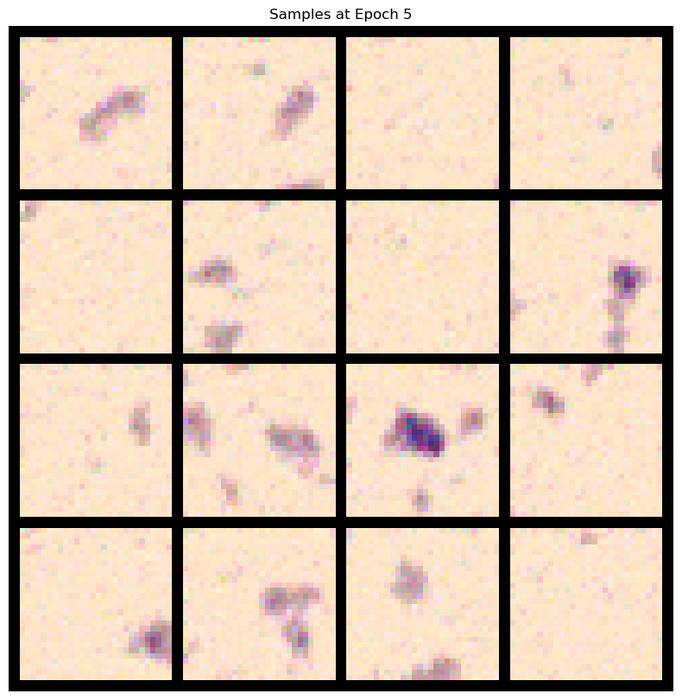

Epoch 6/30 | Train Loss: 3.775114 | Val Loss: 3.793268
New best validation loss: 3.793268


Epoch 7/30 | Train Loss: 3.761862 | Val Loss: 3.723110
New best validation loss: 3.723110


Epoch 8/30 | Train Loss: 3.806525 | Val Loss: 3.820395
No improvement for 1 epochs


Epoch 9/30 | Train Loss: 3.757415 | Val Loss: 3.666081
New best validation loss: 3.666081


Epoch 10/30 | Train Loss: 3.779198 | Val Loss: 3.722831
No improvement for 1 epochs


...

Epoch 12/30 | Train Loss: 3.713491 | Val Loss: 3.768029
No improvement for 3 epochs


Epoch 13/30 | Train Loss: 3.703705 | Val Loss: 3.687469
No improvement for 4 epochs


Epoch 14/30 | Train Loss: 3.651596 | Val Loss: 3.631081
New best validation loss: 3.631081


Epoch 15/30 | Train Loss: 3.610107 | Val Loss: 3.614130
New best validation loss: 3.614130


Generating rows: 100%|██████████| 28/28 [00:05<00:00,  5.15it/s]


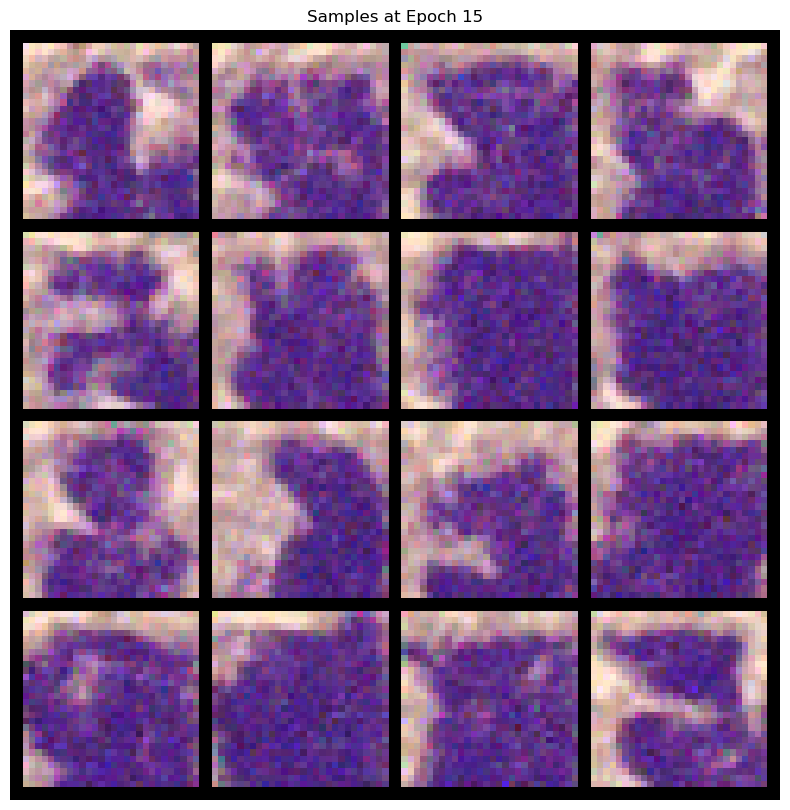

Epoch 16/30 | Train Loss: 3.601334 | Val Loss: 3.620167
No improvement for 1 epochs


Epoch 17/30 | Train Loss: 3.590849 | Val Loss: 3.597138
New best validation loss: 3.597138


Epoch 18/30 | Train Loss: 3.584464 | Val Loss: 3.592850
New best validation loss: 3.592850


Epoch 19/30 | Train Loss: 3.576879 | Val Loss: 3.571804
New best validation loss: 3.571804


Epoch 20/30 | Train Loss: 3.568774 | Val Loss: 3.571684
New best validation loss: 3.571684


Generating rows: 100%|██████████| 28/28 [00:05<00:00,  5.15it/s]


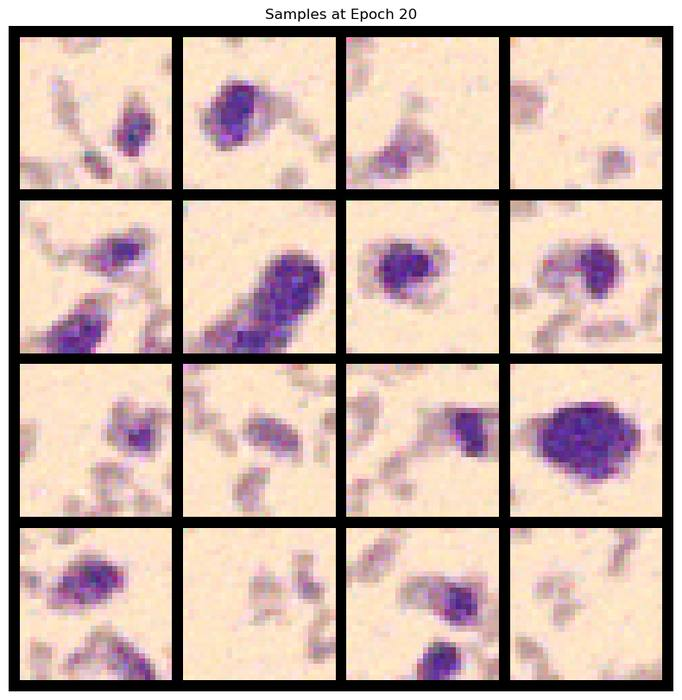

Epoch 21/30 | Train Loss: 3.566404 | Val Loss: 3.575226
No improvement for 1 epochs


Epoch 22/30 | Train Loss: 3.557167 | Val Loss: 3.582073
No improvement for 2 epochs


Epoch 23/30 | Train Loss: 3.542558 | Val Loss: 3.545881
New best validation loss: 3.545881


Epoch 24/30 | Train Loss: 3.541172 | Val Loss: 3.549238
No improvement for 1 epochs


Epoch 25/30 | Train Loss: 3.575993 | Val Loss: 3.552866
No improvement for 2 epochs


...

Epoch 27/30 | Train Loss: 3.520240 | Val Loss: 3.529922
No improvement for 1 epochs


Epoch 28/30 | Train Loss: 3.523303 | Val Loss: 3.585140
No improvement for 2 epochs


Epoch 29/30 | Train Loss: 3.581725 | Val Loss: 3.561006
No improvement for 3 epochs


Epoch 30/30 | Train Loss: 3.516883 | Val Loss: 3.480110
New best validation loss: 3.480110


Generating rows: 100%|██████████| 28/28 [00:05<00:00,  5.15it/s]


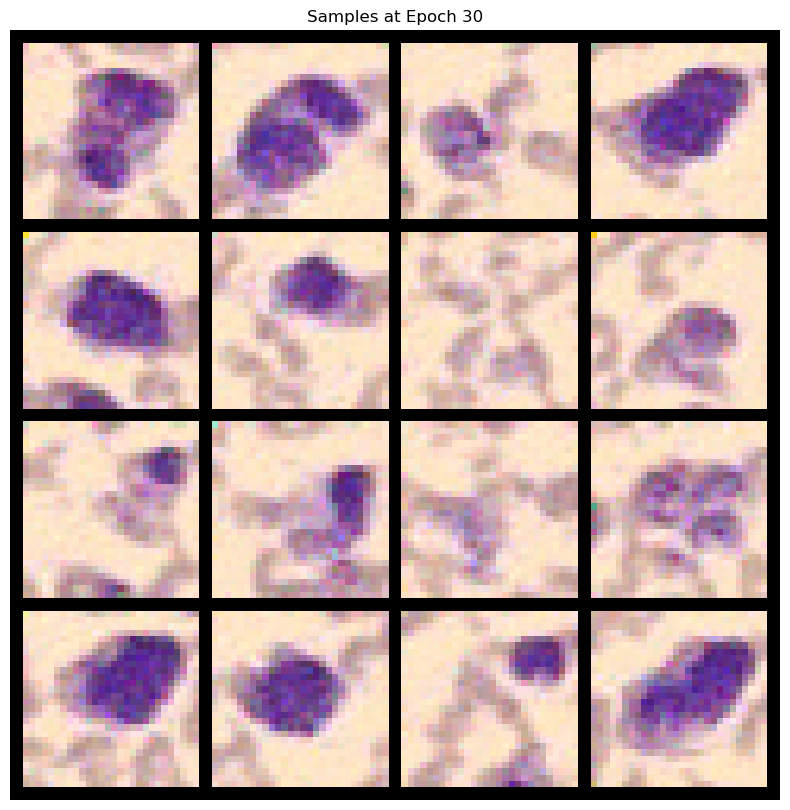

Generating rows: 100%|██████████| 28/28 [00:15<00:00,  1.80it/s]


FID Score for combination 8: 164.0503


Generating rows: 100%|██████████| 28/28 [00:05<00:00,  4.95it/s]


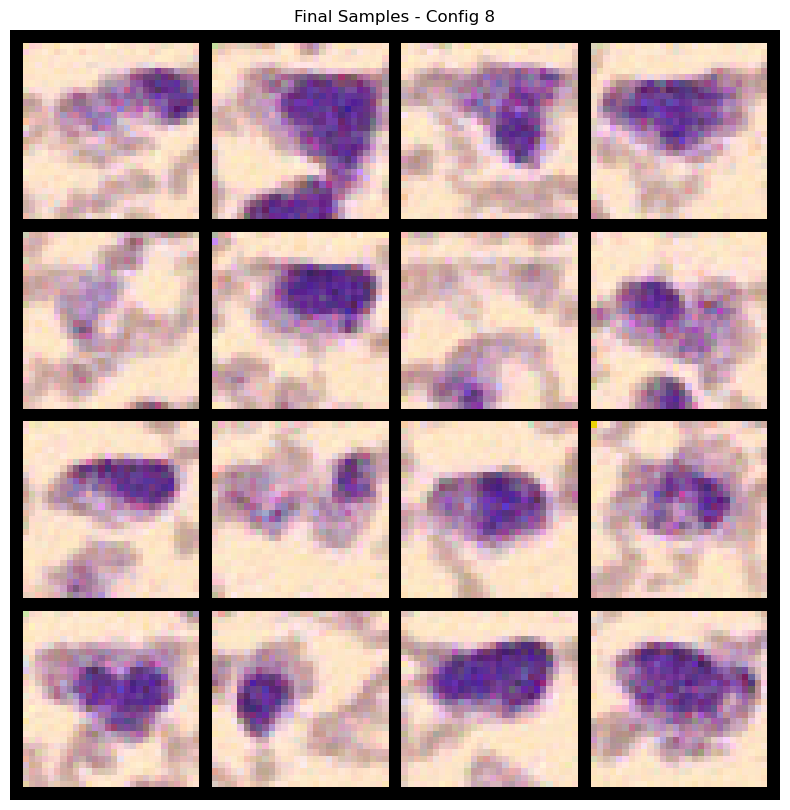


=== Best Hyperparameter Configuration ===
Best combination: 1/8
Best FID Score: 152.1049
Configuration: {'epochs': 30, 'hidden_dim': 64, 'lr': 0.001, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-05}
Model successfully loaded from checkpoint_0.pth

==== Final evaluation with multiple seeds ====

=== Evaluating PixelCNN with Multiple Seeds ===


<HOME>\AppData\Local\Temp\ipykernel_22996\2106350901.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'pixelcnn_checkpoint_{best_idx}.pth')



Evaluation 1/5 with seed 42
Training with seed 42


Epoch 1/30 | Train Loss: 4.737979 | Val Loss: 4.372079


Epoch 2/30 | Train Loss: 4.124734 | Val Loss: 3.971598


...

Epoch 22/30 | Train Loss: 3.699636 | Val Loss: 3.648684


Epoch 23/30 | Train Loss: 3.690249 | Val Loss: 3.730546


Epoch 24/30 | Train Loss: 3.681349 | Val Loss: 3.655928


Epoch 25/30 | Train Loss: 3.673727 | Val Loss: 3.662900
Early stopping at epoch 25


Generating rows: 100%|██████████| 28/28 [00:02<00:00, 10.26it/s]


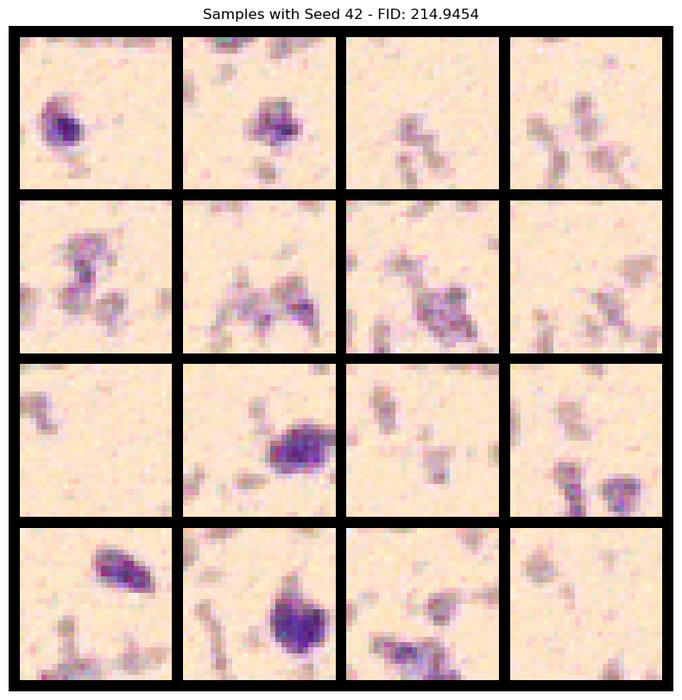


Evaluation 2/5 with seed 123
Training with seed 123


Epoch 1/30 | Train Loss: 4.730860 | Val Loss: 4.337615


Epoch 2/30 | Train Loss: 4.151496 | Val Loss: 4.046987


Epoch 3/30 | Train Loss: 3.982609 | Val Loss: 3.986298


Epoch 4/30 | Train Loss: 3.896151 | Val Loss: 3.834233


...

Epoch 27/30 | Train Loss: 3.549125 | Val Loss: 3.576359


Epoch 28/30 | Train Loss: 3.588768 | Val Loss: 3.548239


Epoch 29/30 | Train Loss: 3.528817 | Val Loss: 3.532232


Epoch 30/30 | Train Loss: 3.522404 | Val Loss: 3.593144


Generating rows: 100%|██████████| 28/28 [00:02<00:00, 10.32it/s]


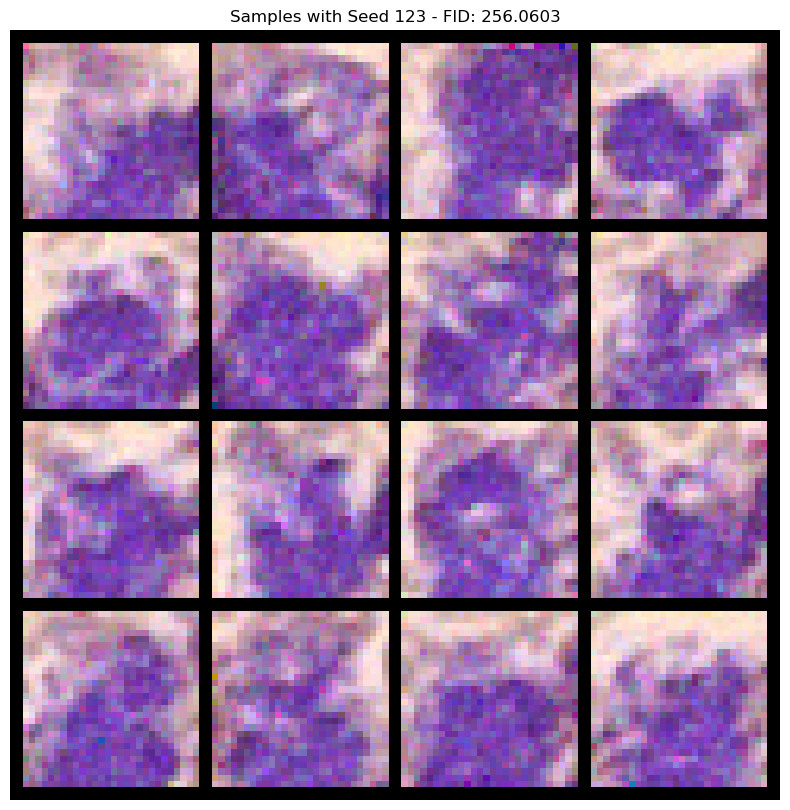


Evaluation 3/5 with seed 456
Training with seed 456


Epoch 1/30 | Train Loss: 4.715467 | Val Loss: 4.317292


Epoch 2/30 | Train Loss: 4.145710 | Val Loss: 4.123450


Epoch 3/30 | Train Loss: 4.001227 | Val Loss: 3.939210


Epoch 4/30 | Train Loss: 3.922969 | Val Loss: 3.922964


...

Epoch 27/30 | Train Loss: 3.578869 | Val Loss: 3.586331


Epoch 28/30 | Train Loss: 3.575930 | Val Loss: 3.573631


Epoch 29/30 | Train Loss: 3.625670 | Val Loss: 3.663944


Epoch 30/30 | Train Loss: 3.624778 | Val Loss: 3.586965


Generating rows: 100%|██████████| 28/28 [00:02<00:00, 10.50it/s]


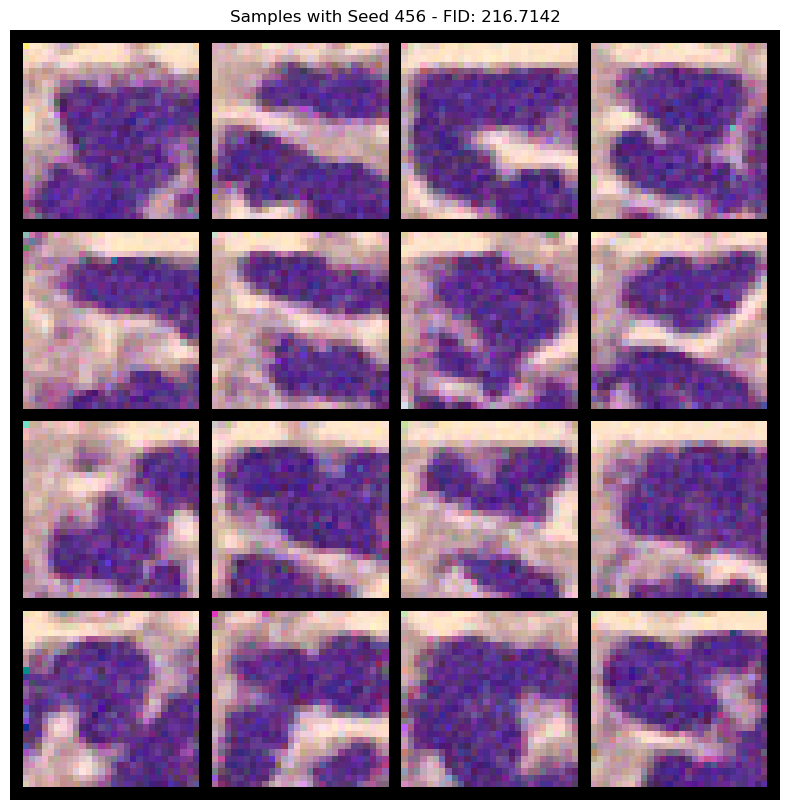


Evaluation 4/5 with seed 789
Training with seed 789


Epoch 1/30 | Train Loss: 4.721424 | Val Loss: 4.312480


Epoch 2/30 | Train Loss: 4.098172 | Val Loss: 4.005112


Epoch 3/30 | Train Loss: 3.919107 | Val Loss: 3.887852


Epoch 4/30 | Train Loss: 3.830997 | Val Loss: 3.805122


...

Epoch 27/30 | Train Loss: 3.678733 | Val Loss: 3.588349


Epoch 28/30 | Train Loss: 3.701361 | Val Loss: 3.650639


Epoch 29/30 | Train Loss: 3.583240 | Val Loss: 3.577078


Epoch 30/30 | Train Loss: 3.559830 | Val Loss: 3.553206


Generating rows: 100%|██████████| 28/28 [00:02<00:00, 10.21it/s]


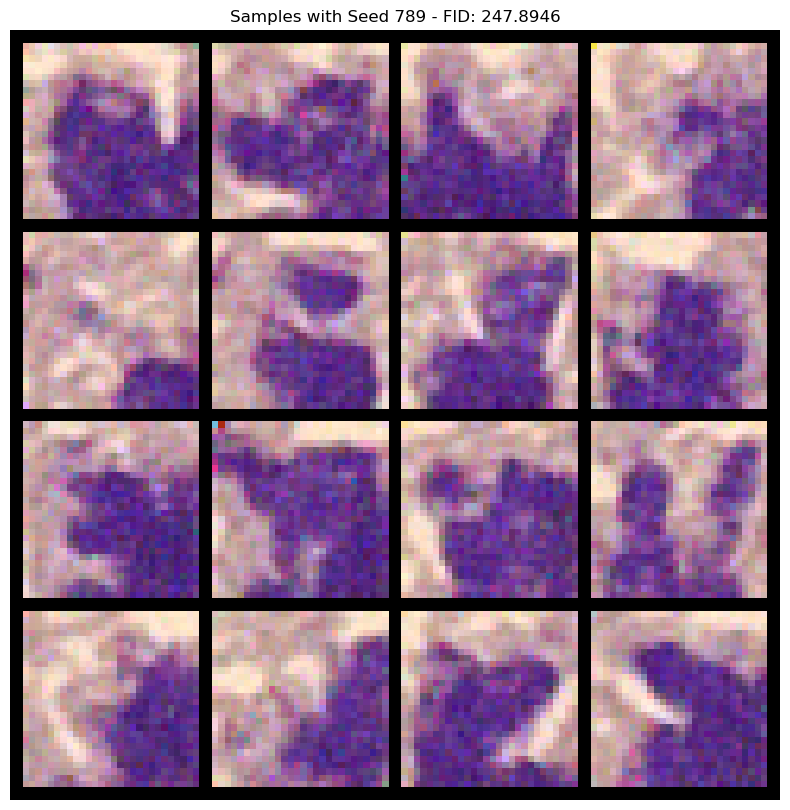


Evaluation 5/5 with seed 1010
Training with seed 1010


Epoch 1/30 | Train Loss: 4.717789 | Val Loss: 4.336266


Epoch 2/30 | Train Loss: 4.139112 | Val Loss: 3.994294


Epoch 3/30 | Train Loss: 3.972852 | Val Loss: 3.949918


Epoch 4/30 | Train Loss: 3.883503 | Val Loss: 3.839226


...

Epoch 27/30 | Train Loss: 3.612914 | Val Loss: 3.577999


Epoch 28/30 | Train Loss: 3.570313 | Val Loss: 3.600596


Epoch 29/30 | Train Loss: 3.551209 | Val Loss: 3.549456


Epoch 30/30 | Train Loss: 3.643599 | Val Loss: 3.559938


Generating rows: 100%|██████████| 28/28 [00:02<00:00, 10.57it/s]


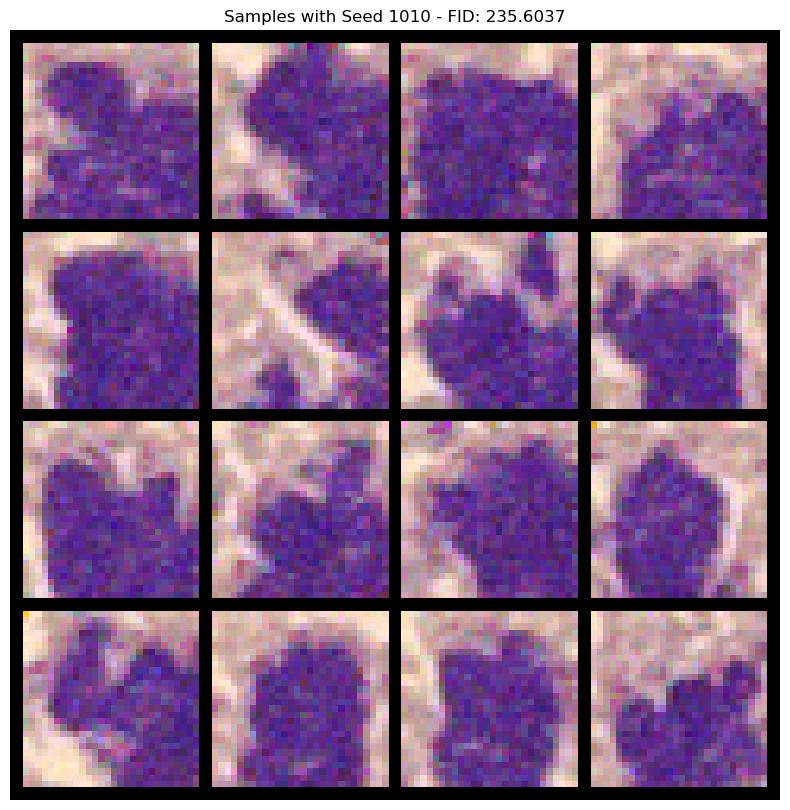


=== Robustness Evaluation Results ===
Mean FID Score: 234.2436 ± 16.3943
Evaluation 1 (Seed 42): FID = 214.9454
Evaluation 2 (Seed 123): FID = 256.0603
Evaluation 3 (Seed 456): FID = 216.7142
Evaluation 4 (Seed 789): FID = 247.8946
Evaluation 5 (Seed 1010): FID = 235.6037


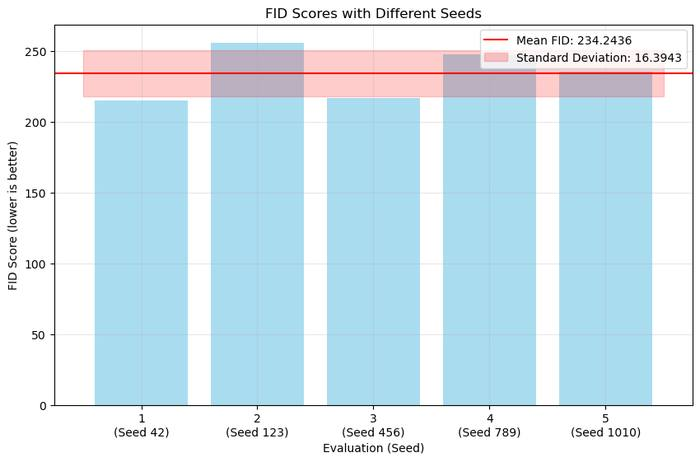

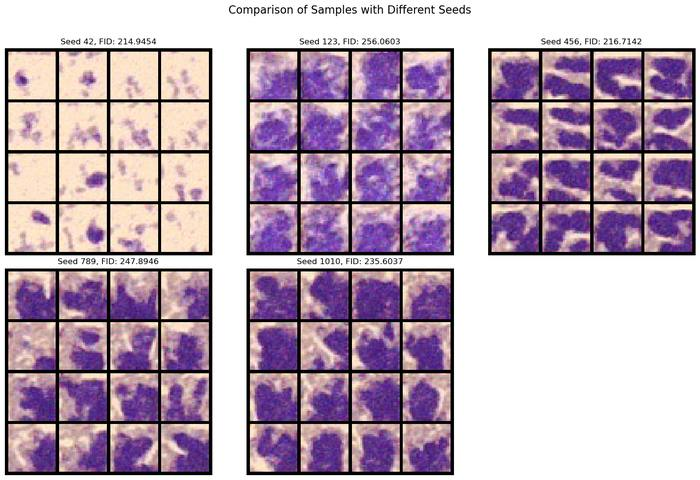


==== Final Results Summary ====
Best model hyperparameters: {'epochs': 30, 'hidden_dim': 64, 'lr': 0.001, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-05}
Best single model FID: 152.1049
Mean FID across 5 seeds: 234.2436 ± 16.3943
Total trainable parameters: 285,120

Generating final sample grid...


Generating rows: 100%|██████████| 28/28 [00:04<00:00,  5.93it/s]


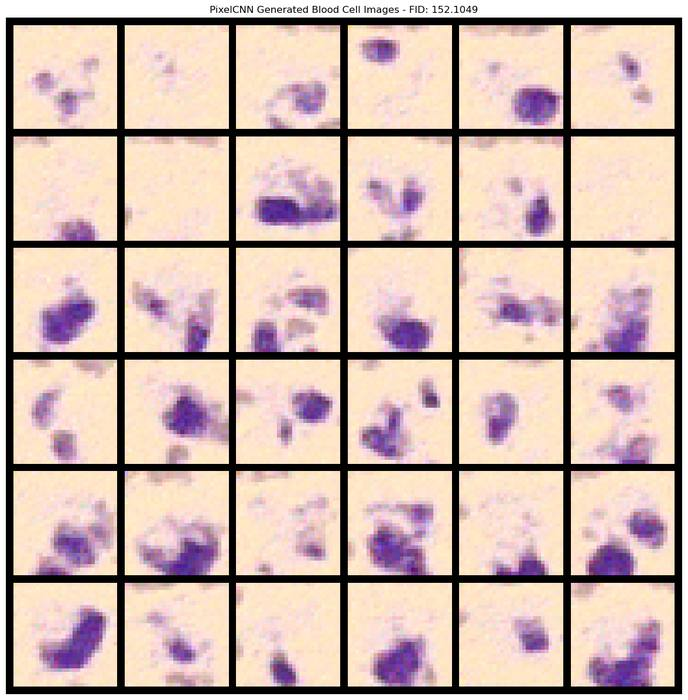


Comparing real and generated images...


Generating rows: 100%|██████████| 28/28 [00:03<00:00,  7.64it/s]


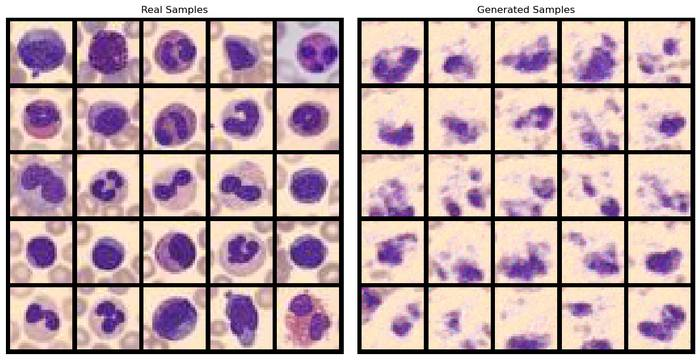

In [ ]:
# Define configuration for the 8th hyperparameter combination
hyperparams_8 = {
    'hidden_dim': 96,               # Width of the hidden layers
    'n_residual_blocks': 5,         # Number of residual blocks in the network
    'use_residual': True,           # Whether to use residual connections
    'lr': 5e-4,                     # Learning rate for the optimizer
    'epochs': 30,                   # Maximum number of training epochs
    'weight_decay': 1e-5,           # L2 regularization factor
    'patience': 10                  # Early stopping patience (epochs)
}

# Set quantization level for pixels
n_bits = 8  # Using 8 bits allows for 256 possible pixel values

print("Training only combination 8...")
# Initialize model with the specified configuration and seed
set_seed(INITIAL_SEED + 7)  # Use a consistent seed for reproducibility
model_8 = PixelCNN(
    input_channels=n_channels,      # Number of image channels from dataset
    hidden_dim=hyperparams_8['hidden_dim'],
    n_residual_blocks=hyperparams_8['n_residual_blocks'],
    n_bits=n_bits,
    use_residual=hyperparams_8['use_residual']
).to(DEVICE)  # Move model to GPU if available

# Train the model with early stopping based on validation loss
trained_model_8, train_losses_8, val_losses_8, best_val_loss_8 = train_pixelcnn(
    model_8,
    train_loader,
    val_loader,
    hyperparams_8,
    DEVICE,
    n_bits=n_bits,
    patience=hyperparams_8['patience']
)

# FID evaluation settings
n_samples_fid = 500  # Number of samples to generate for FID calculation
batch_size = 50      # Generate in smaller batches to avoid CUDA OOM errors
real_batch, _ = next(iter(test_loader))
real_samples = real_batch[:n_samples_fid].to(DEVICE)

# Generate samples in batches to conserve memory
# This is crucial for GPUs with limited VRAM
fake_samples_8 = []
for i in range(0, n_samples_fid, batch_size):
    # Calculate the actual batch size for the current iteration
    batch_size_i = min(batch_size, n_samples_fid - i)
    # Generate a batch of samples
    batch_samples = generate_samples(trained_model_8, n_samples=batch_size_i, device=DEVICE)
    # Move generated samples to CPU to free GPU memory
    fake_samples_8.append(batch_samples.cpu())
    # Clear GPU cache after each batch
    torch.cuda.empty_cache()

# Concatenate all batches and move back to GPU for FID calculation
fake_samples_8 = torch.cat(fake_samples_8, dim=0).to(DEVICE)
# Calculate FID score between real and generated samples
fid_score_8 = compute_fid(real_samples, fake_samples_8, batch_size=32, device=DEVICE)
print(f"FID Score for combination 8: {fid_score_8:.4f}")

# Visualize a small set of generated samples
vis_samples = generate_samples(trained_model_8, n_samples=16, device=DEVICE)
visualize_samples(vis_samples, title=f"Final Samples - Config 8")

# Save the training results for future reference
result_8 = {
    'hyperparams': hyperparams_8,
    'best_val_loss': best_val_loss_8,
    'fid_score': fid_score_8,
    'model_state': trained_model_8.state_dict(),
    'train_losses': train_losses_8,
    'val_losses': val_losses_8
}

torch.save({
    'result': result_8,
}, 'pixelcnn_checkpoint_7.pth')

# List of FID results from all hyperparameter combinations (1-8)
# Lower FID scores indicate better quality of generated images
fid_scores = [152.1049, 243.0661, 230.8094, 154.9189, 228.8498, 230.0, 229.1984, fid_score_8]
hyperparams_list = [
    {'epochs': 30, 'hidden_dim': 64, 'lr': 0.001, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 64, 'lr': 0.001, 'n_residual_blocks': 5, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 64, 'lr': 0.0005, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 64, 'lr': 0.0005, 'n_residual_blocks': 5, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 96, 'lr': 0.001, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 96, 'lr': 0.001, 'n_residual_blocks': 5, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    {'epochs': 30, 'hidden_dim': 96, 'lr': 0.0005, 'n_residual_blocks': 3, 'patience': 10, 'use_residual': True, 'weight_decay': 1e-5},
    hyperparams_8
]

# Find the best hyperparameter configuration based on FID score
best_idx = np.argmin(fid_scores)  # Index of lowest FID score
best_fid = fid_scores[best_idx]
best_hyperparams = hyperparams_list[best_idx]

print(f"\n=== Best Hyperparameter Configuration ===")
print(f"Best combination: {best_idx + 1}/8")
print(f"Best FID Score: {best_fid:.4f}")
print(f"Configuration: {best_hyperparams}")

# Select the best model based on FID scores
if best_idx == 7:  # If combination 8 is the best
    best_result = result_8
    best_model = trained_model_8
else:
    # Load the best model from previous checkpoints
    best_model = PixelCNN(
        input_channels=n_channels,
        hidden_dim=best_hyperparams['hidden_dim'],
        n_residual_blocks=best_hyperparams['n_residual_blocks'],
        n_bits=n_bits,
        use_residual=best_hyperparams['use_residual']
    ).to(DEVICE)
    
    try:
        # Attempt to load the saved model checkpoint
        checkpoint = torch.load(f'pixelcnn_checkpoint_{best_idx}.pth')
        # Handle different checkpoint formats
        if 'results' in checkpoint:
            # Old checkpoint format
            best_result = checkpoint['results'][0]
        else:
            # New checkpoint format
            best_result = checkpoint['result']
        
        best_model.load_state_dict(best_result['model_state'])
        print(f"Model successfully loaded from checkpoint_{best_idx}.pth")
    except Exception as e:
        print(f"Error loading model: {e}")
        if best_idx == 0:  # Fallback to model 8 if best model is unavailable
            print("Using combination 8 model as fallback")
            best_model = trained_model_8
            best_result = result_8

# Perform robust evaluation using multiple random seeds
print("\n==== Final evaluation with multiple seeds ====")
seeds = [42, 123, 456, 789, 1010]  # 5 different seeds for robustness analysis

final_results = evaluate_with_multiple_seeds(
    model_class=PixelCNN,
    best_hyperparams=best_hyperparams,
    train_loader=train_loader,
    test_loader=test_loader,
    seeds=seeds,
    device=DEVICE,
    n_bits=n_bits,
    n_samples_fid=500
)

# Display final evaluation results
print("\n==== Final Results Summary ====")
print(f"Best model hyperparameters: {best_hyperparams}")
print(f"Best single model FID: {best_fid:.4f}")
print(f"Mean FID across 5 seeds: {final_results['mean_fid']:.4f} ± {final_results['std_fid']:.4f}")

# Calculate and display model complexity (number of parameters)
params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {params:,}")

# Generate a final grid of samples for visualization
print("\nGenerating final sample grid...")
with torch.no_grad():
    # Temperature of 0.8 gives a good balance between quality and diversity
    final_samples = generate_samples(best_model, n_samples=36, device=DEVICE, temp=0.8)
    
    grid = make_grid(final_samples, nrow=6)
    plt.figure(figsize=(15, 15))
    plt.axis('off')
    plt.title(f"PixelCNN Generated Blood Cell Images - FID: {best_fid:.4f}")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

# Compare real and generated samples side by side
print("\nComparing real and generated images...")
compare_real_and_generated(best_model, test_loader, n_samples=25, device=DEVICE)